In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 

In [7]:
data = pd.read_csv('Crop_Recommendation_randomised.csv')
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,33,59,22,22.642369,21.593961,5.947000,122.388601,KidneyBeans
1,77,36,23,24.714175,56.734265,6.648725,88.453619,Maize
2,59,55,19,31.743795,62.510077,7.332375,68.970975,Blackgram
3,9,69,20,19.306073,23.963628,5.591561,129.344933,KidneyBeans
4,9,38,25,34.585615,50.340353,5.497947,100.306072,Mango


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [9]:
x = data.drop('Crop', axis=1)
y = data['Crop']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
nbrs = KNeighborsClassifier(n_neighbors=7, algorithm='auto').fit(x_train, y_train)


In [ ]:
nbrs.score(x_test, y_test) 

0.9840909090909091

In [50]:
data.iloc[0]

Nitrogen                33
Phosphorus              59
Potassium               22
Temperature      22.642369
Humidity         21.593961
pH_Value             5.947
Rainfall        122.388601
Crop           KidneyBeans
Name: 0, dtype: object

In [53]:
neigh=nbrs.kneighbors(data.iloc[0].drop('Crop').values.reshape(1, -1))
neigh[0]

/home/mark/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([[ 0.        ,  7.55989699,  8.68894114,  9.85152872,  9.90830809,
        11.73371764, 13.10321785]])

In [55]:
data.columns

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Crop'],
      dtype='object')

In [ ]:
centrods = data.groupby('Crop')[['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']].mean()
centrods

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
Crop,,,,,,,
Apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
Banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
Blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
ChickPea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
Coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
Coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
Cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
Grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
Jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


In [ ]:
x_optimal = centrods.values
knn

/tmp/ipykernel_6226/3617436100.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


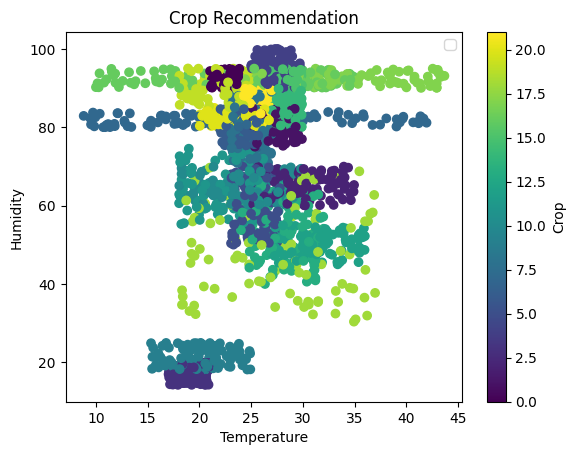

In [26]:
plt.scatter(x['Temperature'], x['Humidity'], c=y.astype('category').cat.codes, cmap='viridis')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.title('Crop Recommendation')
plt.colorbar(label='Crop')
plt.legend()
plt.show()